Celda 1 – Imports y configuración

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, bernoulli, norm, binom




Celda 2 – Poisson: paquetes defectuosos

In [3]:
lam = 3  # media de la Poisson
k = 2    # número de defectuosos

# Cálculo teórico con la fórmula de Poisson
p_poisson_formula = (lam**k * math.exp(-lam)) / math.factorial(k)

# Cálculo usando scipy.stats.poisson (para verificar)
p_poisson_scipy = poisson.pmf(k, mu=lam)

p_poisson_formula, p_poisson_scipy


(0.22404180765538775, np.float64(0.22404180765538775))

Celda 3 – Bernoulli: chip especial

In [4]:
p_chip = 0.05

# Distribución Bernoulli: P(X=1) = p, P(X=0) = 1-p
p_tiene_chip = p_chip
p_no_tiene_chip = 1 - p_chip

p_tiene_chip, p_no_tiene_chip


(0.05, 0.95)

Celda 4 – Normal: peso entre 140 y 160 g

In [5]:
mu = 150
sigma = 10

z1 = (140 - mu) / sigma
z2 = (160 - mu) / sigma

p_entre_140_160 = norm.cdf(z2) - norm.cdf(z1)
p_entre_140_160, p_entre_140_160 * 100


(np.float64(0.6826894921370859), np.float64(68.26894921370858))

Celda 5 – Gráfico de la Normal

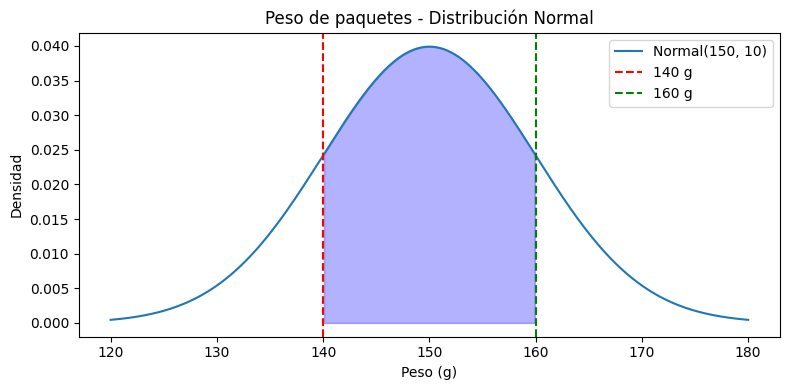

In [6]:
x = np.linspace(120, 180, 500)
pdf = norm.pdf(x, mu, sigma)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, label="Normal(150, 10)")
plt.axvline(140, color="red", linestyle="--", label="140 g")
plt.axvline(160, color="green", linestyle="--", label="160 g")
plt.fill_between(x, pdf, where=(x >= 140) & (x <= 160),
                 alpha=0.3, color="blue")
plt.title("Peso de paquetes - Distribución Normal")
plt.xlabel("Peso (g)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()


Celda 6 – Monte Carlo Binomial

In [7]:
n = 50
p = p_chip

num_sim = 100_000

data_binomial = binom.rvs(n=n, p=p, size=num_sim)

media_simulada = data_binomial.mean()
media_teorica = n * p

media_simulada, media_teorica


(np.float64(2.50332), 2.5)

Celda 7 – Histograma vs binomial teórica

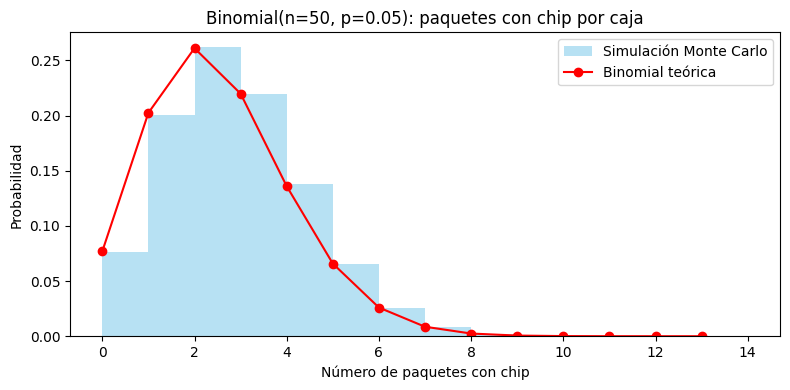

In [8]:
valores = np.arange(0, data_binomial.max() + 1)
pmf_teorica = binom.pmf(valores, n=n, p=p)

plt.figure(figsize=(8, 4))
plt.hist(data_binomial,
         bins=range(0, data_binomial.max() + 2),
         density=True,
         alpha=0.6,
         color="skyblue",
         label="Simulación Monte Carlo")

plt.plot(valores, pmf_teorica, "o-", color="red", label="Binomial teórica")
plt.title("Binomial(n=50, p=0.05): paquetes con chip por caja")
plt.xlabel("Número de paquetes con chip")
plt.ylabel("Probabilidad")
plt.legend()
plt.tight_layout()
plt.show()
